### **1. Download Annual Daily Weather Files for Vancouver Station**

In [ ]:
import pandas as pd
import requests
import io
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define Vancouver station ID and year range
station_id = 51442
years = range(2015, 2025)
output_dir = '/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather'

os.makedirs(output_dir, exist_ok=True)

base_url = "https://climate.weather.gc.ca/climate_data/bulk_data_e.html"

for year in years:
    params = {
        "format": "csv",
        "stationID": station_id,
        "Year": year,
        "timeframe": 2,  # 2 = daily data
        "submit": "Download Data"
    }

    out_path = f"{output_dir}/station_{station_id}_{year}.csv"

    try:
        r = requests.get(base_url, params=params)
        if r.status_code == 200 and "Date/Time" in r.text:
            with open(out_path, "wb") as f:
                f.write(r.content)
            print(f"Downloaded {station_id} ({year})")
        else:
            print(f"Data missing for {station_id} ({year})")
    except Exception as e:
        print(f"Error for {station_id} ({year}): {e}")


Mounted at /content/drive
Downloaded 51442 (2015)
Downloaded 51442 (2016)
Downloaded 51442 (2017)
Downloaded 51442 (2018)
Downloaded 51442 (2019)
Downloaded 51442 (2020)
Downloaded 51442 (2021)
Downloaded 51442 (2022)
Downloaded 51442 (2023)
Downloaded 51442 (2024)


### **2. Combine Annual Weather Files to get a Single Weather File**

In [ ]:
import pandas as pd
import os
import glob

# Set up file locations
input_dir = '/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather'
output_dir = '/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather_Combined'
os.makedirs(output_dir, exist_ok=True)

# Vancouver station ID and name
station_id = 51442
city = 'Vancouver'

# Columns to keep after merge
merge_cols = [
    "Longitude (x)", "Latitude (y)", "Station Name", "Climate ID",
    "Date/Time", "Year", "Month", "Day",
    "Max Temp (°C)", "Min Temp (°C)", "Mean Temp (°C)"
]

# Find all annual daily weather files
files = sorted(glob.glob(os.path.join(input_dir, f'*{station_id}*.csv')))
if not files:
    print(f'No files found for {city} ({station_id})')
else:
    # Read and filter all files found for Vancouver
    dfs = []
    for file in files:
        try:
            df = pd.read_csv(file)
            df = df[[c for c in merge_cols if c in df.columns]]
            dfs.append(df)
        except Exception as e:
            print(f'Error reading {file}: {e}')

    if dfs:
        # Concatenate and clean files
        combined = pd.concat(dfs, ignore_index=True)
        combined = combined.drop_duplicates(subset='Date/Time')
        combined["Date/Time"] = pd.to_datetime(combined["Date/Time"], errors="coerce")
        combined = combined.dropna(subset=["Date/Time"]).sort_values("Date/Time")

        # Save combined file for Vancouver
        output_path = os.path.join(output_dir, f'{city}_2015_2024_daily.csv')
        combined.to_csv(output_path, index=False)
        print(f'Combined file saved to {output_path}')
    else:
        print(f'No valid data for {city}')


Combined file saved to /content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather_Combined/Vancouver_2015_2024_daily.csv


### **3. Explore and Clean Merged Dataset**

In [ ]:
import numpy as np
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataframe
van_df = pd.read_csv('/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather_Combined/Vancouver_2015_2024_daily.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Check for Missing Values in Average Temperature and Date/Time Columns

In [ ]:
import pandas as pd

# Check for missing average temp data
missing_van = van_df['Mean Temp (°C)'].isna().sum()

print(f'Missing Values in Mean Temp (°C) Column:')
print(f'Vancouver: {missing_van}')

# Check for missing dates
# Ensure dates are in datetime format and sorted
van_df['Date/Time'] = pd.to_datetime(van_df['Date/Time'])
van_df = van_df.sort_values('Date/Time')

# Compute missing days based on full expected date range
van_date_range = pd.date_range(van_df['Date/Time'].min(), van_df['Date/Time'].max(), freq='D')
van_missing_dates = van_date_range.difference(van_df['Date/Time'])

# Print results
print(f'Missing Days in Date/Time Column:')
print(f"Vancouver Dataset: {len(van_missing_dates)} missing days")
if len(van_missing_dates) > 0:
    for date in van_missing_dates:
        print(date.date())

Missing Values in Mean Temp (°C) Column:
Vancouver: 47
Missing Days in Date/Time Column:
Vancouver Dataset: 0 missing days


### Now we need to find where the missing average temperature values are (i.e., consecutive or non-consecutive empty values) and then decide how to fill them in

In [ ]:
## VANCOUVER STATION

import pandas as pd

# Make sure Date/Time column is in datetime format
van_df['Date/Time'] = pd.to_datetime(van_df['Date/Time'])

# Sort by date
van_df = van_df.sort_values('Date/Time').reset_index(drop=True)

# Identify the indices where Mean Temp (°C) is missing
missing_positions = van_df.index[van_df['Mean Temp (°C)'].isna()].to_list()

# If there are missing values, find consecutive runs
if missing_positions:
    consecutive_runs = []
    run = [missing_positions[0]]

    for i in range(1, len(missing_positions)):
        if missing_positions[i] == missing_positions[i - 1] + 1:
            run.append(missing_positions[i])
        else:
            consecutive_runs.append(run)
            run = [missing_positions[i]]
    consecutive_runs.append(run)

    # Summarize
    print(f"Number of missing runs: {len(consecutive_runs)}")

    # Show the date ranges for each run
    print("\nMissing date ranges for Vancouver:")
    for run in consecutive_runs:
        start_date = van_df.loc[run[0], 'Date/Time']
        end_date = van_df.loc[run[-1], 'Date/Time']
        print(f"{start_date.date()} → {end_date.date()} ({len(run)} days)")
else:
    print("No missing Mean Temp values found.")


Number of missing runs: 42

Missing date ranges for Vancouver:
2015-06-15 → 2015-06-15 (1 days)
2016-02-18 → 2016-02-18 (1 days)
2016-07-07 → 2016-07-07 (1 days)
2016-10-02 → 2016-10-02 (1 days)
2017-04-23 → 2017-04-23 (1 days)
2017-10-25 → 2017-10-25 (1 days)
2017-11-07 → 2017-11-08 (2 days)
2018-08-18 → 2018-08-18 (1 days)
2020-03-06 → 2020-03-06 (1 days)
2020-03-14 → 2020-03-14 (1 days)
2020-03-20 → 2020-03-20 (1 days)
2021-05-12 → 2021-05-12 (1 days)
2021-06-15 → 2021-06-15 (1 days)
2021-06-20 → 2021-06-20 (1 days)
2021-11-18 → 2021-11-18 (1 days)
2022-05-06 → 2022-05-06 (1 days)
2022-07-14 → 2022-07-14 (1 days)
2022-08-10 → 2022-08-11 (2 days)
2022-08-31 → 2022-09-01 (2 days)
2022-09-19 → 2022-09-19 (1 days)
2022-10-11 → 2022-10-11 (1 days)
2023-03-30 → 2023-03-30 (1 days)
2023-04-02 → 2023-04-02 (1 days)
2023-05-20 → 2023-05-20 (1 days)
2023-05-22 → 2023-05-22 (1 days)
2023-11-15 → 2023-11-15 (1 days)
2023-11-20 → 2023-11-20 (1 days)
2024-01-09 → 2024-01-09 (1 days)
2024-01-17 → 

### Fill in missing values in the Vancouver dataset using linear interpolation (given only 1 or 2 day missing values)

In [ ]:
import pandas as pd
import numpy as np

# Keep original df copy
van_df_orig = van_df.copy()

# Fill in missing values on a duplicate df
van_df_filled = van_df.copy()

# Ensure Date/Time column is in the proper format and is sorted
van_df_filled['Date/Time'] = pd.to_datetime(van_df_filled['Date/Time'])
van_df_filled = van_df_filled.sort_values('Date/Time').reset_index(drop=True)

# Fill missing values via linear interpolation
van_df_filled['Mean Temp (°C)'] = van_df_filled['Mean Temp (°C)'].interpolate(method='linear', limit_direction='both')

# Check if missing values remain
remain_missing = van_df_filled['Mean Temp (°C)'].isna().sum()
print(f'Missing values remaining: {remain_missing}')


Missing values remaining: 0


In [ ]:
# Save filled in df for pre-processing and analysis steps
van_df_filled.to_csv('/content/drive/MyDrive/MATH663_Project/Project_Data/Daily_Weather_Combined/Vancouver_2015_2024_daily_filled.csv', index=True)


### **4. Visualize Data Using Mean Temperature Time Series Graph**

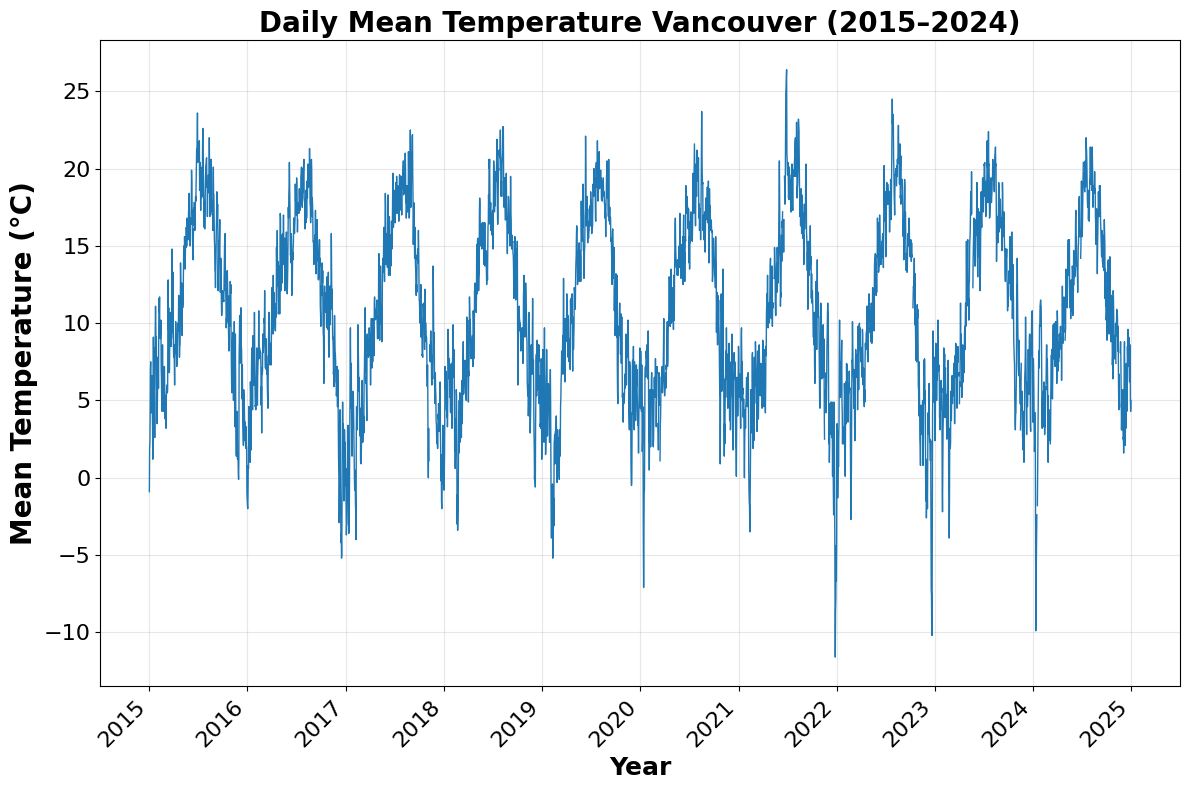

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure Date/Time column reads properly
van_df['Date/Time'] = pd.to_datetime(van_df['Date/Time'], errors='coerce')

# Plot time series for each station
plt.figure(figsize=(12, 8))

plt.plot(van_df['Date/Time'], van_df['Mean Temp (°C)'], label='Vancouver', linewidth=1)

# Format x-axis to show only years
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())        # tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # show as YYYY
ax.tick_params(axis='both', which='major', labelsize=16)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')  # tilt slightly for readability

# Labels and formatting
plt.title('Daily Mean Temperature Vancouver (2015–2024)', fontweight='bold', fontsize=20)
plt.xlabel('Year', fontweight='bold', fontsize=18)
plt.ylabel('Mean Temperature (°C)', fontweight='bold', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()